   edad  edad2
0    80   6400
1    26    676
2    27    729
3    71   5041
4    54   2916


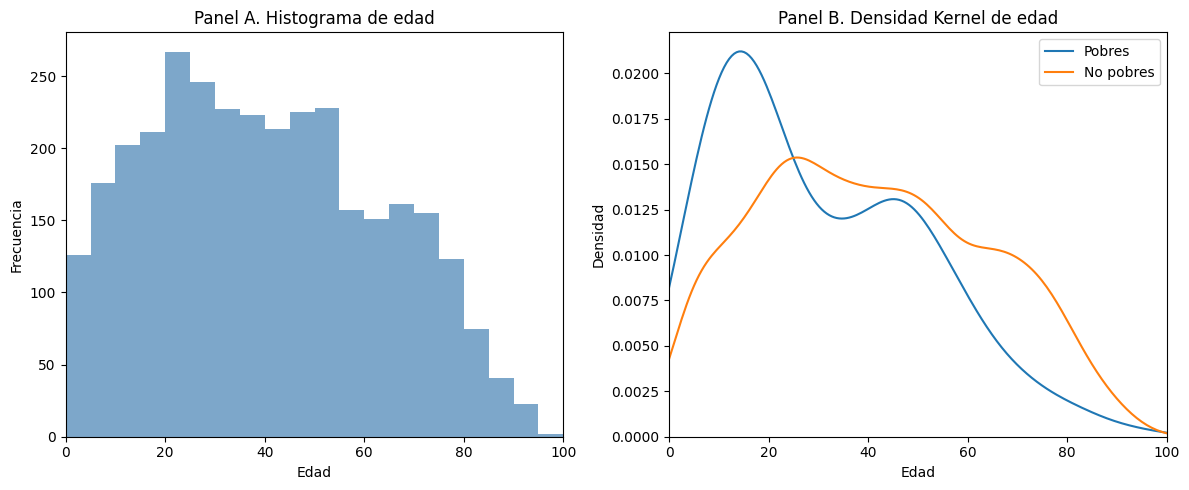

In [15]:
#PARTE 1-1
# en este paso importo librerías
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# en este paso fijo carpeta y archivo
PATH_BASES = Path.cwd()
file_resp = PATH_BASES / "respondieron.xlsx"

# en este paso cargo la base
df = pd.read_excel(file_resp, dtype="object")

# en este paso tipifico variables usadas
df["edad"] = pd.to_numeric(df.get("edad"), errors="coerce")
df["pobre"] = pd.to_numeric(df.get("pobre"), errors="coerce")

# en este paso creo edad2 = edad al cuadrado
df = df[df["edad"].notna()].copy()
df["edad2"] = df["edad"] ** 2

# en este paso verifico la nueva variable
print(df[["edad", "edad2"]].head())

# en este paso preparo los datos para kernels
pobres = df[df["pobre"] == 1]["edad"].dropna()
no_pobres = df[df["pobre"] == 0]["edad"].dropna()

# en este paso grafico paneles A y B
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: histograma de edad
bins_ = np.arange(0, int(df["edad"].max()) + 5, 5)
axes[0].hist(df["edad"].dropna(), bins=bins_, alpha=0.7, color="steelblue")
axes[0].set_title("Panel A. Histograma de edad")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Frecuencia")
axes[0].set_xlim(0, 100)

# Panel B: kernels de edad por condición de pobreza
sns.kdeplot(pobres, ax=axes[1], label="Pobres", clip=(0, 100))
sns.kdeplot(no_pobres, ax=axes[1], label="No pobres", clip=(0, 100))
axes[1].set_title("Panel B. Densidad Kernel de edad")
axes[1].set_xlabel("Edad")
axes[1].set_ylabel("Densidad")
axes[1].legend()
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

# en este paso guardo la base actualizada
df.to_excel(file_resp, index=False)

In [16]:
#PARTE 1-2
# en este paso importo librerías
import pandas as pd
import numpy as np
from pathlib import Path

# en este paso fijo carpeta y archivo
PATH_BASES = Path.cwd()
file_resp = PATH_BASES / "respondieron.xlsx"

# en este paso cargo la base
df = pd.read_excel(file_resp, dtype="object")

# en este paso detecto la columna de nivel educativo
candidatas = ["nivel_educ"]
nivel_col = next((c for c in candidatas if c in df.columns), None)
if nivel_col is None:
    raise ValueError("No encuentro la columna de nivel educativo en respondieron.xlsx")

# en este paso tipifico la variable educativa
df[nivel_col] = pd.to_numeric(df[nivel_col], errors="coerce")

# en este paso defino el mapeo a años de educación según tus reglas
#  primario completo=6, secundario completo=12 total, universitario completo=17 total
#  incompletos=mitad del completo, sin instrucción=0, posgrado completo=+2 (19)
map_educ = {
    7: 0,   # sin instrucción
    1: 3,   # primario incompleto
    2: 6,   # primario completo
    3: 9,   # secundario incompleto
    4: 12,  # secundario completo
    5: 15,  # superior/universitario incompleto
    6: 17,  # superior/universitario completo
    8: 19   # posgrado universitario completo
}

# en este paso creo la variable educ
df["educ"] = df[nivel_col].map(map_educ).astype("float")

# en este paso muestro chequeo rápido
print("Columna educativa usada:", nivel_col)
print("Valores no mapeados:", sorted(v for v in df[nivel_col].dropna().unique() if v not in map_educ))

# en este paso guardo la base actualizada
df.to_excel(file_resp, index=False)

print("Listo, agregué 'educ' a respondieron.xlsx")

# en este paso calculo estadísticos descriptivos de años de educación
stats = df["educ"].agg(["mean", "std", "min", "median", "max"]).rename({
    "mean": "promedio",
    "std": "desvío_std",
    "min": "mínimo",
    "median": "p50",
    "max": "máximo"
})

# en este paso muestro resultados
print("Estadísticas descriptivas de años de educación:")
print(stats)

# en este paso guardo tabla en Excel
out = pd.DataFrame(stats).T
out.to_excel(PATH_BASES / "estadisticas_educParte1-2.xlsx", index=False)

Columna educativa usada: nivel_educ
Valores no mapeados: []
Listo, agregué 'educ' a respondieron.xlsx
Estadísticas descriptivas de años de educación:
promedio      10.968750
desvío_std     5.273863
mínimo         0.000000
p50           12.000000
máximo        17.000000
Name: educ, dtype: float64


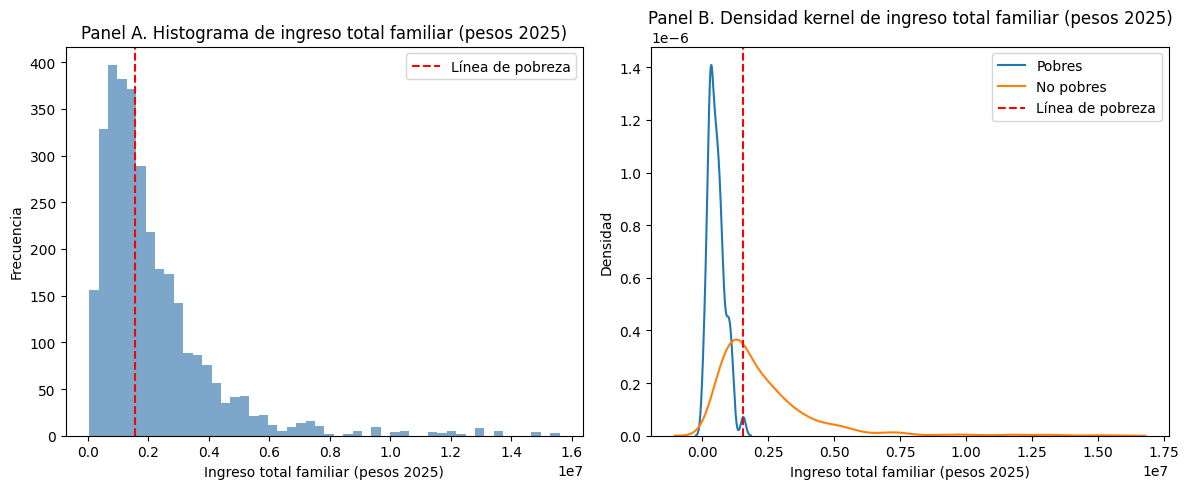

Listo, se creó 'ingreso_total_familiar' ajustado a precios 2025 y se graficaron los paneles.


In [17]:
# PARTE 1-3
# en este paso importo librerías
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# en este paso fijo carpeta y archivo
PATH_BASES = Path.cwd()
file_resp = PATH_BASES / "respondieron.xlsx"

# en este paso cargo la base
df = pd.read_excel(file_resp)

# en este paso tipifico variables clave
df["anio"] = pd.to_numeric(df.get("anio"), errors="coerce")
df["ITF"] = pd.to_numeric(df.get("ITF"), errors="coerce")
df["pobre"] = pd.to_numeric(df.get("pobre"), errors="coerce")

# en este paso creo variable ingreso_total_familiar (ITF ajustado a precios 2025)
factor_inflacion = 1 + 94803.91 / 100
df["ingreso_total_familiar"] = np.where(
    df["anio"] == 2005,
    df["ITF"] * factor_inflacion,
    df["ITF"]
)

# en este paso calculo línea de pobreza implícita según variable pobre
# uso el máximo ingreso entre pobres como umbral
linea_pobreza = df.loc[df["pobre"] == 1, "ingreso_total_familiar"].max()

# en este paso preparo datos para kernel
pobres = df.loc[df["pobre"] == 1, "ingreso_total_familiar"].dropna()
no_pobres = df.loc[df["pobre"] == 0, "ingreso_total_familiar"].dropna()

# en este paso grafico paneles A y B
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: histograma de ingreso_total_familiar
axes[0].hist(df["ingreso_total_familiar"].dropna(), bins=50, color="steelblue", alpha=0.7)
axes[0].axvline(linea_pobreza, color="red", linestyle="--", label="Línea de pobreza")
axes[0].set_title("Panel A. Histograma de ingreso total familiar (pesos 2025)")
axes[0].set_xlabel("Ingreso total familiar (pesos 2025)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Panel B: densidad kernel por condición de pobreza
sns.kdeplot(pobres, ax=axes[1], label="Pobres")
sns.kdeplot(no_pobres, ax=axes[1], label="No pobres")
axes[1].axvline(linea_pobreza, color="red", linestyle="--", label="Línea de pobreza")
axes[1].set_title("Panel B. Densidad kernel de ingreso total familiar (pesos 2025)")
axes[1].set_xlabel("Ingreso total familiar (pesos 2025)")
axes[1].set_ylabel("Densidad")
axes[1].legend()

plt.tight_layout()
plt.show()

# en este paso guardo la base actualizada
df.to_excel(file_resp, index=False)

print("Listo, se creó 'ingreso_total_familiar' ajustado a precios 2025 y se graficaron los paneles.")


Para seguir con el siguiente punto obtuvimos la base de 2005 y agregamos la variable por que no la teniamos del tp anterior. hacemos lo mismo para 2025. agarramos las variables de interes y la mergeamos a nuestra base de datos final.

In [18]:
#Parte 1-4
import pandas as pd

# Cargar bases
usu_2025 = pd.read_excel("usu_individual_T125.xlsx", usecols=["CODUSU", "NRO_HOGAR", "PP3E_TOT", "PP3F_TOT"])
ind_2005 = pd.read_excel("ind-t105.xlsx", usecols=["CODUSU,C,8", "NRO_HOGAR,N,1,0", "PP3E_TOT", "PP3F_TOT"])
respondieron = pd.read_excel("respondieron.xlsx")

# Renombrar columnas 2005
ind_2005 = ind_2005.rename(columns={
    "CODUSU,C,8": "CODUSU",
    "NRO_HOGAR,N,1,0": "NRO_HOGAR"
})

# Crear identificadores homogéneos
ind_2005["HOGAR_ID"] = ind_2005["CODUSU"].astype(str) + "_" + ind_2005["NRO_HOGAR"].astype(str)
usu_2025["HOGAR_ID"] = usu_2025["CODUSU"].astype(str) + "_" + usu_2025["NRO_HOGAR"].astype(str)

# Agregar año y concatenar
usu_2025["anio"] = 2025
ind_2005["anio"] = 2005

horas_total = pd.concat([usu_2025, ind_2005], ignore_index=True)
horas_total["horastrab"] = horas_total[["PP3E_TOT", "PP3F_TOT"]].fillna(0).sum(axis=1)

# Armar equivalentes en respondieron
respondieron["HOGAR_ID"] = (
    respondieron["Distincion_vivienda_individuo"].astype(str)
    + "_"
    + respondieron["Distincion_vivienda_hogar"].astype(str)
)

# Merge con respondieron
respondieron_final = respondieron.merge(
    horas_total[["HOGAR_ID", "horastrab"]],
    on="HOGAR_ID",
    how="left"
)

# Filtrar jefes y calcular estadísticas
jefes = respondieron_final[respondieron_final["parentesco"].astype(str).str.contains("Jefe", case=False, na=False)]
stats_horas = jefes["horastrab"].agg(["mean", "std", "min", "median", "max"]).round(2)

# Guardar resultados
respondieron_final.to_excel("respondieron_final.xlsx", index=False)
print(stats_horas)



mean     NaN
std      NaN
min      NaN
median   NaN
max      NaN
Name: horastrab, dtype: float64


Lo que sucede aqui es que mergeo pero tenemos valores nulos de 2005, no deberia de suceder. arreglamos y seguimos

In [23]:
import pandas as pd

# Cargar bases
usu_2025 = pd.read_excel("usu_individual_T125.xlsx", usecols=["CODUSU", "NRO_HOGAR", "PP3E_TOT", "PP3F_TOT"])
ind_2005 = pd.read_excel("ind-t105.xlsx")
respondieron = pd.read_excel("respondieron.xlsx")

# Limpiar y preparar base 2005
ind_2005 = ind_2005.rename(columns={
    'CODUSU,C,8': 'CODUSU',
    'NRO_HOGAR,N,1,0': 'NRO_HOGAR'
})
ind_2005 = ind_2005[['CODUSU', 'NRO_HOGAR', 'PP3E_TOT', 'PP3F_TOT']]

# Crear HOGAR_ID y limpiar espacios
ind_2005["HOGAR_ID"] = (ind_2005["CODUSU"].astype(str) + "_" + ind_2005["NRO_HOGAR"].astype(str)).str.strip()
usu_2025["HOGAR_ID"] = (usu_2025["CODUSU"].astype(str) + "_" + usu_2025["NRO_HOGAR"].astype(str)).str.strip()

# Agregar año
usu_2025["anio"] = 2025
ind_2005["anio"] = 2005

# Unir bases de horas
horas_total = pd.concat([usu_2025, ind_2005], ignore_index=True)
horas_total["horastrab"] = horas_total[["PP3E_TOT", "PP3F_TOT"]].fillna(0).sum(axis=1)

# Preparar respondieron - LIMPIAR ESPACIOS
respondieron["HOGAR_ID"] = (
    respondieron["Distincion_vivienda_individuo"].astype(str).str.strip() + "_" + 
    respondieron["Distincion_vivienda_hogar"].astype(str).str.strip()
)

# Merge simple
respondieron_final = respondieron.merge(
    horas_total[["HOGAR_ID", "horastrab"]],
    on="HOGAR_ID",
    how="left"
)

respondieron_final["parentesco"] = respondieron_final["parentesco"].astype(str)

# Estadísticas básicas
print("=== RESULTADOS ===")
print(f"Registros totales: {len(respondieron_final)}")
print(f"Registros con horas: {respondieron_final['horastrab'].notna().sum()}")

# Jefes
jefes = respondieron_final[respondieron_final["parentesco"].str.contains("Jefe", na=False)]
print(f"Jefes con horas: {jefes['horastrab'].notna().sum()}")

if jefes['horastrab'].notna().sum() > 0:
    stats = jefes["horastrab"].agg(["mean", "std", "min", "median", "max"]).round(2)
    print("\nEstadísticas horas jefes:")
    print(stats)

# Guardar
respondieron_final.to_excel("respondieron_final.xlsx", index=False)
print("\nBase guardada: respondieron_final.xlsx")

=== RESULTADOS ===
Registros totales: 10607
Registros con horas: 10607
Jefes con horas: 0

Base guardada: respondieron_final.xlsx


In [24]:
import pandas as pd
df = pd.read_excel("respondieron_final.xlsx")
print(df["horastrab"].describe().round(2))

count    10607.00
mean        21.35
std         81.12
min          0.00
25%          0.00
50%          0.00
75%         40.00
max       1998.00
Name: horastrab, dtype: float64


Filtrando la base de datos se encuentran valores inhumanos de trabajo, los dropeamos para que no intervengan en el analisis.

In [25]:
import pandas as pd
df = pd.read_excel("respondieron_final.xlsx")
df = df[~df["horastrab"].isin([999, 1083, 1998])]
print(df["horastrab"].describe().round(2))

count    10553.00
mean        15.94
std         22.58
min          0.00
25%          0.00
50%          0.00
75%         40.00
max        105.00
Name: horastrab, dtype: float64


In [1]:
# PARTE 1-5 - Tamaño de la base y resumen por año
import pandas as pd
from pathlib import Path

# en este paso fijo carpeta y archivo
PATH_BASES = Path.cwd()
file_resp = PATH_BASES / "respondieron_final.xlsx"

# en este paso cargo la base
df = pd.read_excel(file_resp)

# en este paso creo la tabla resumen
tabla = (
    df.groupby("anio")
    .agg(
        Cantidad_observaciones=("pobre", "size"),
        Observaciones_con_NA=("pobre", lambda x: x.isna().sum()),
        Cantidad_Pobres=("pobre", lambda x: (x == 1).sum()),
        Cantidad_No_Pobres=("pobre", lambda x: (x == 0).sum())
    )
    .reset_index()
)

# agrego fila total
tabla.loc["Total"] = [
    "Total",
    tabla["Cantidad_observaciones"].sum(),
    tabla["Observaciones_con_NA"].sum(),
    tabla["Cantidad_Pobres"].sum(),
    tabla["Cantidad_No_Pobres"].sum()
]

# agrego cantidad de variables limpias
tabla["Variables_limpias_homog"] = df.shape[1]

# muestro tabla en formato más legible
print("Tabla 1. Resumen de la base final para la región YYY\n")
print(tabla.to_string(index=False))


Tabla 1. Resumen de la base final para la región YYY

 anio  Cantidad_observaciones  Observaciones_con_NA  Cantidad_Pobres  Cantidad_No_Pobres  Variables_limpias_homog
 2005                    7984                     0             1021                6963                       31
 2025                    2623                     0              467                2156                       31
Total                   10607                     0             1488                9119                       31


---

#  A) "PCA"

=== 1. MATRIZ DE CORRELACIONES ===
Variables disponibles para el análisis: ['edad', 'edad2', 'educ', 'ITF', 'n_personas', 'horastrab']


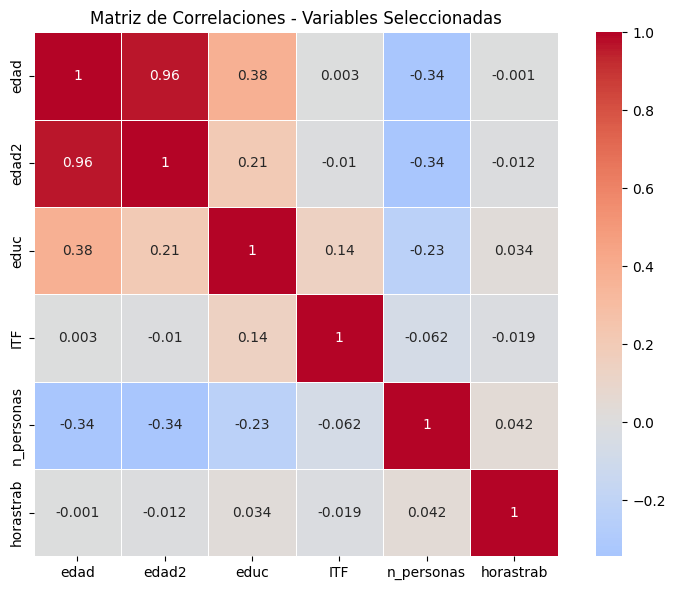

Matriz de correlaciones:
             edad  edad2   educ    ITF  n_personas  horastrab
edad        1.000  0.960  0.376  0.003      -0.342     -0.001
edad2       0.960  1.000  0.207 -0.010      -0.343     -0.012
educ        0.376  0.207  1.000  0.142      -0.226      0.034
ITF         0.003 -0.010  0.142  1.000      -0.062     -0.019
n_personas -0.342 -0.343 -0.226 -0.062       1.000      0.042
horastrab  -0.001 -0.012  0.034 -0.019       0.042      1.000


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Cargar la base de datos
df = pd.read_excel("respondieron_final.xlsx")

# 1. MATRIZ DE CORRELACIONES
print("=== 1. MATRIZ DE CORRELACIONES ===")

# Seleccionar las variables requeridas
variables_pca = ['edad', 'edad2', 'educ', 'ITF', 'n_personas', 'horastrab']

# Filtrar solo las variables que existen en el dataframe
variables_disponibles = [var for var in variables_pca if var in df.columns]
print(f"Variables disponibles para el análisis: {variables_disponibles}")

# Crear matriz de correlaciones
corr_matrix = df[variables_disponibles].corr().round(3)

# Graficar matriz de correlaciones
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Matriz de Correlaciones - Variables Seleccionadas')
plt.tight_layout()
plt.show()

print("Matriz de correlaciones:")
print(corr_matrix)




=== 2. PCA CON INGRESO ===
Tamaño de la muestra para PCA: (10607, 6)


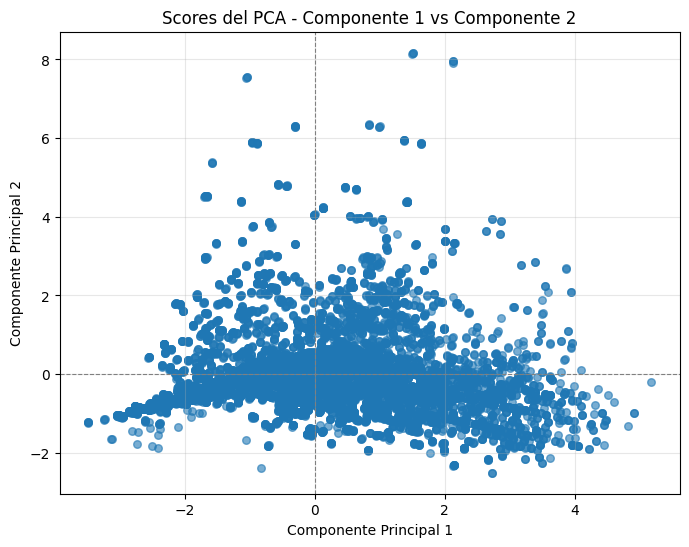

In [27]:
# 2. PCA CON INGRESO
print("\n=== 2. PCA CON INGRESO ===")

# Preparar datos para PCA
X = df[variables_disponibles].copy()

# Eliminar valores faltantes
X = X.dropna()

print(f"Tamaño de la muestra para PCA: {X.shape}")

# Estandarizar variables
scaler = StandardScaler(with_std=True, with_mean=True)
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=variables_disponibles)

# Aplicar PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled_df)

# Scores del primer y segundo componente
scores = X_pca

# Gráfico de dispersión de scores (Componente 1 vs Componente 2)
plt.figure(figsize=(8, 6))
plt.scatter(scores[:, 0], scores[:, 1], alpha=0.6, s=30)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Scores del PCA - Componente 1 vs Componente 2')
plt.grid(True, alpha=0.3)
plt.show()




=== 3. PONDERADORES (LOADINGS) ===


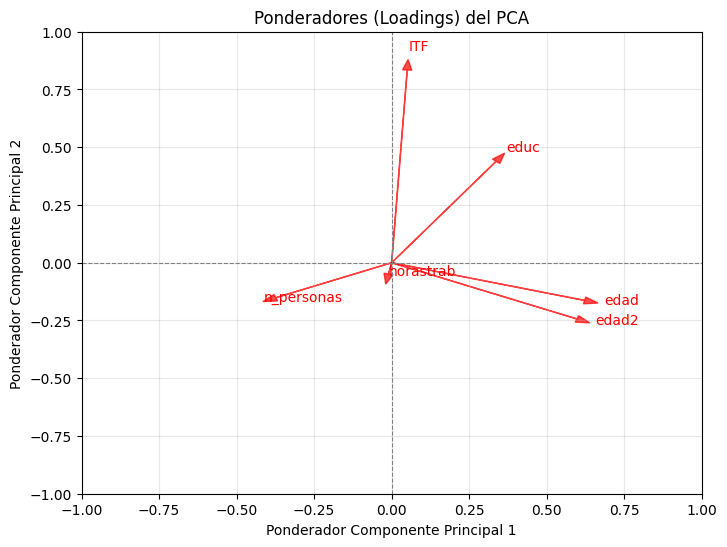

Loadings del Componente Principal 1:
  edad: 0.622
  edad2: 0.597
  educ: 0.337
  ITF: 0.050
  n_personas: -0.374
  horastrab: -0.010

Loadings del Componente Principal 2:
  edad: -0.163
  edad2: -0.243
  educ: 0.439
  ITF: 0.834
  n_personas: -0.151
  horastrab: -0.048

=== 4. PROPORCIÓN DE VARIANZA EXPLICADA ===
Proporción de varianza explicada por cada componente:
Componente 1: 0.389 (38.9%)
Componente 2: 0.182 (18.2%)
Componente 3: 0.169 (16.9%)
Componente 4: 0.131 (13.1%)
Componente 5: 0.126 (12.6%)
Componente 6: 0.004 (0.4%)

Varianza acumulada total: 1.000


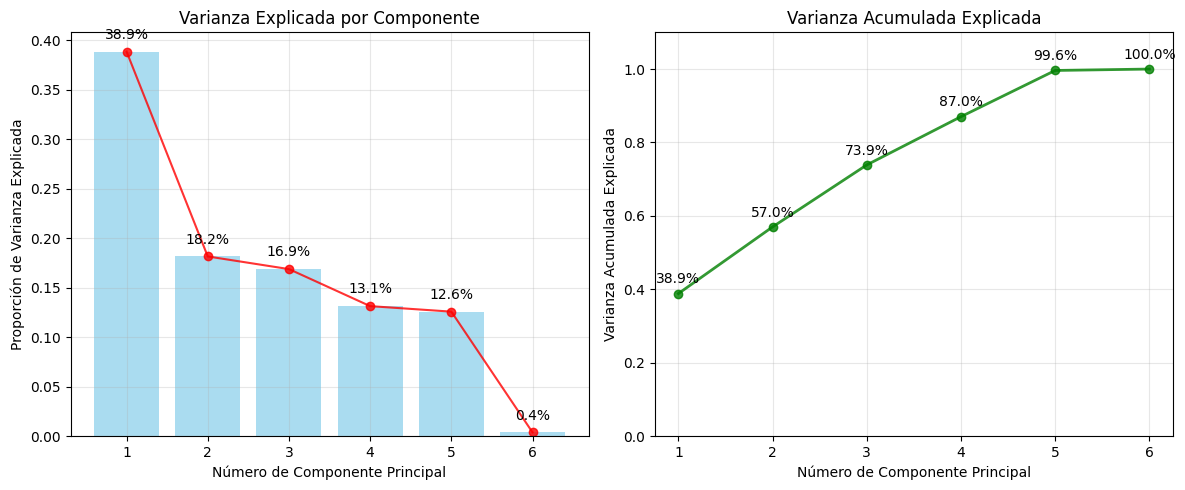


=== RESUMEN FINAL ===
Total de componentes: 6
Varianza explicada por los primeros 2 componentes: 0.570 (57.0%)
Varianza explicada por los primeros 3 componentes: 0.739 (73.9%)


In [28]:
# 3. GRÁFICO DE PONDERADORES (LOADINGS)
print("\n=== 3. PONDERADORES (LOADINGS) ===")

# Loadings vectors
loadings = pca.components_

# Gráfico de ponderadores
plt.figure(figsize=(8, 6))
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)

# Dibujar flechas de ponderadores
for i in range(loadings.shape[1]):
    plt.arrow(0, 0, loadings[0, i], loadings[1, i], 
              color='red', head_width=0.03, alpha=0.7)
    plt.text(loadings[0, i] * 1.1, loadings[1, i] * 1.1, 
             variables_disponibles[i], color='red', fontsize=10)

plt.xlabel('Ponderador Componente Principal 1')
plt.ylabel('Ponderador Componente Principal 2')
plt.title('Ponderadores (Loadings) del PCA')
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.grid(True, alpha=0.3)
plt.show()

# Mostrar valores numéricos de los loadings
print("Loadings del Componente Principal 1:")
for i, var in enumerate(variables_disponibles):
    print(f"  {var}: {loadings[0, i]:.3f}")

print("\nLoadings del Componente Principal 2:")
for i, var in enumerate(variables_disponibles):
    print(f"  {var}: {loadings[1, i]:.3f}")

# 4. PROPORCIÓN DE VARIANZA EXPLICADA
print("\n=== 4. PROPORCIÓN DE VARIANZA EXPLICADA ===")

# Varianza explicada
var_explicada = pca.explained_variance_ratio_
var_acumulada = np.cumsum(var_explicada)

print("Proporción de varianza explicada por cada componente:")
for i, var in enumerate(var_explicada):
    print(f"Componente {i+1}: {var:.3f} ({var*100:.1f}%)")

print(f"\nVarianza acumulada total: {var_acumulada[-1]:.3f}")

# Gráfico de varianza explicada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de varianza individual
componentes = range(1, len(var_explicada) + 1)
ax1.bar(componentes, var_explicada, alpha=0.7, color='skyblue')
ax1.plot(componentes, var_explicada, 'ro-', alpha=0.8)
ax1.set_xlabel('Número de Componente Principal')
ax1.set_ylabel('Proporción de Varianza Explicada')
ax1.set_title('Varianza Explicada por Componente')
ax1.set_xticks(componentes)
ax1.grid(True, alpha=0.3)

# Gráfico de varianza acumulada
ax2.plot(componentes, var_acumulada, 'go-', alpha=0.8, linewidth=2)
ax2.set_xlabel('Número de Componente Principal')
ax2.set_ylabel('Varianza Acumulada Explicada')
ax2.set_title('Varianza Acumulada Explicada')
ax2.set_xticks(componentes)
ax2.set_ylim(0, 1.1)
ax2.grid(True, alpha=0.3)

# Añadir anotaciones de porcentaje
for i, (v, va) in enumerate(zip(var_explicada, var_acumulada)):
    ax1.text(i+1, v + 0.01, f'{v*100:.1f}%', ha='center', va='bottom')
    ax2.text(i+1, va + 0.02, f'{va*100:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# RESUMEN FINAL
print("\n=== RESUMEN FINAL ===")
print(f"Total de componentes: {len(var_explicada)}")
print(f"Varianza explicada por los primeros 2 componentes: {var_acumulada[1]:.3f} ({var_acumulada[1]*100:.1f}%)")
print(f"Varianza explicada por los primeros 3 componentes: {var_acumulada[2]:.3f} ({var_acumulada[2]*100:.1f}%)")